In [1]:
# Install required packages
!pip install -q scipy pandas matplotlib seaborn tqdm pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.1 MB/s eta 0:00:00


In [2]:
# Clone the repository and add src to sys.path
import os
import sys

REPO_ROOT = '/content/antenna-gnn'

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/asparagusD/antenna_gnn.git {REPO_ROOT}
else:
    !cd {REPO_ROOT} && git pull

if f'{REPO_ROOT}/src' not in sys.path:
    sys.path.insert(0, f'{REPO_ROOT}/src')

Cloning into '/content/antenna-gnn'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (299/299), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 299 (delta 156), reused 255 (delta 114), pack-reused 0 (from 0)
Receiving objects: 100% (299/299), 6.33 MiB | 18.77 MiB/s, done.
Resolving deltas: 100% (156/156), done.


In [3]:
# Mount Google Drive and set data paths
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_ROOT = '/content/drive/MyDrive/antenna_gnn'
RAW_DATA = '/content/drive/MyDrive/antenna_dataset'

# Create necessary directories in DATA_ROOT
os.makedirs(f'{DATA_ROOT}/artifacts', exist_ok=True)
os.makedirs(f'{DATA_ROOT}/figures', exist_ok=True)

Mounted at /content/drive


### Cell A — Discover the dataset layout


In [5]:
import os, glob, time
import scipy.io as sio
from collections import defaultdict
from tqdm.auto import tqdm

NOTEBOOK_T0 = time.time()
print("=== Discover the dataset layout ===")

def print_tree(directory, level=0, max_level=2, max_files=4):
    if level > max_level:
        return
    print("  " * level + f"|-- {os.path.basename(directory) or directory}/")
    try:
        entries = sorted(os.listdir(directory))
    except (PermissionError, FileNotFoundError):
        return
    dirs  = [e for e in entries if os.path.isdir(os.path.join(directory, e))]
    files = [e for e in entries if not os.path.isdir(os.path.join(directory, e))]
    for e in dirs:
        print_tree(os.path.join(directory, e), level + 1, max_level, max_files)
    for e in files[:max_files]:
        print("  " * (level + 1) + f"|-- {e}")
    if len(files) > max_files:
        print("  " * (level + 1) + f"|-- ... {len(files) - max_files} more files")

print_tree(RAW_DATA)

all_mat_files = sorted(list(tqdm(glob.iglob(f'{RAW_DATA}/**/*.mat', recursive=True), desc="Discovering .mat files")))
print(f"\nTotal .mat files found: {len(all_mat_files):,}")
assert all_mat_files, f"No .mat files under {RAW_DATA}"

# Group by IMMEDIATE parent directory. The original used
# os.path.dirname(os.path.dirname(f)) — the GRANDparent — which collapses a
# RAW_DATA/<grid>/file.mat layout into a single group and assigns every file to
# whichever grid the first sample happened to be. It also matched membership with
# str.startswith, so '/a/25' would swallow '/a/255'.
by_dir = defaultdict(list)
for f in tqdm(all_mat_files, desc="Grouping files by directory"):
    by_dir[os.path.dirname(f)].append(f)
print(f"Distinct parent directories: {len(by_dir)}")

def grid_of(path):
    return int(sio.loadmat(path)['patch_pattern'].shape[0])

grid_files = defaultdict(list)
mixed_dirs = []
for d, files in sorted(by_dir.items()):
    probe = files[:min(5, len(files))]
    gs = {grid_of(p) for p in probe}
    if len(gs) == 1:
        grid_files[gs.pop()].extend(files)
    else:
        mixed_dirs.append(d)

if mixed_dirs:
    # A directory holding several grid sizes. Fall back to inspecting every file
    # in those directories rather than trusting a probe.
    print(f"WARNING: {len(mixed_dirs)} directory(ies) contain mixed grid sizes; "
          f"inspecting every file in them (slow but correct).")
    files_to_process_in_mixed = []
    for d in mixed_dirs:
        files_to_process_in_mixed.extend(by_dir[d])
    for f in tqdm(files_to_process_in_mixed, desc="Inspecting files in mixed grid directories"):
        grid_files[grid_of(f)].append(f)

grid_files = {k: sorted(v) for k, v in grid_files.items()}
GRIDS = [25, 35, 45, 55]
missing = [g for g in GRIDS if g not in grid_files]
assert not missing, f"Missing grids {missing}; found {sorted(grid_files)}"

print("\nFile counts per grid (this is the ground truth for later assertions):")
DRIVE_COUNTS = {}
for n in GRIDS:
    DRIVE_COUNTS[n] = len(grid_files[n])
    print(f"  {n}x{n}: {DRIVE_COUNTS[n]:,} files   (dir: {os.path.dirname(grid_files[n][0])})")
extra = sorted(set(grid_files) - set(GRIDS))
if extra:
    print(f"  (also present, not analysed: {extra})")

print("\nSchema of one 25x25 sample:")
mat_25 = sio.loadmat(grid_files[25][0])
base_keys = {k for k in mat_25 if not k.startswith('__')}
for k in sorted(base_keys):
    v = mat_25[k]
    print(f"  {k:18} {str(v.shape):10} {v.dtype}")

print("\nSchema check across grids:")
for n in GRIDS[1:]:
    keys = {k for k in sio.loadmat(grid_files[n][0]) if not k.startswith('__')}
    diff = base_keys ^ keys
    print(f"  {n}x{n}: " + ("matches 25x25" if not diff else f"DIFFERS, symmetric diff {diff}"))

est_mb = sum(os.path.getsize(grid_files[n][0]) * DRIVE_COUNTS[n] for n in GRIDS) / 1e6
print(f"\nEstimated total dataset size: ~{est_mb:,.0f} MB")


=== Discover the dataset layout ===
|-- antenna_dataset/
  |-- fine-tuning dataset/
    |-- 35x35/
    |-- 45x45/
    |-- 55x55/
  |-- training dataset/
    |-- 25x25/


Discovering .mat files: 0it [00:00, ?it/s]


Total .mat files found: 114,797


Grouping files by directory:   0%|          | 0/114797 [00:00<?, ?it/s]

Distinct parent directories: 44

File counts per grid (this is the ground truth for later assertions):
  25x25: 99,833 files   (dir: /content/drive/MyDrive/antenna_dataset/training dataset/25x25/Batch-0/Mat_Files)
  35x35: 4,988 files   (dir: /content/drive/MyDrive/antenna_dataset/fine-tuning dataset/35x35/Batch-0/Mat_Files)
  45x45: 6,984 files   (dir: /content/drive/MyDrive/antenna_dataset/fine-tuning dataset/45x45/Batch-0/Mat_Files)
  55x55: 2,992 files   (dir: /content/drive/MyDrive/antenna_dataset/fine-tuning dataset/55x55/Batch-0/Mat_Files)

Schema of one 25x25 sample:
  S11_dB             (1, 201)   float64
  VSWR_full          (1, 201)   float64
  patch_pattern      (25, 25)   uint8
  res_effs           (1, 1)     uint8
  res_gains          (1, 1)     float64
  resonant_bws       (1, 1)     float64
  resonant_freqs     (1, 1)     float64
  resonant_vswrs     (1, 1)     float64

Schema check across grids:
  35x35: matches 25x25
  45x45: matches 25x25
  55x55: matches 25x25

Esti

### Cell B — Stage to local disk
Rationale: The decisive statistic is a mean fill fraction. At n = 6000 the standard error on a fill fraction near 0.7 is about 0.0006, and on a functioning rate about 0.6% — both far finer than the effects being tested (fill 0.71 vs 0.59, functioning 64% vs 48%). Copying all ~115,000 files is therefore unnecessary for the decision, though the cell supports it.


In [6]:
import numpy as np, shutil, concurrent.futures, math
from tqdm.auto import tqdm

LOCAL      = '/content/antenna_dataset'
CONSOL     = '/content/consolidated'
N_WORKERS  = 16          # try 24 or 32 if Drive tolerates it
MAX_PER_GRID = None      # debugging only; None = every file

os.makedirs(LOCAL, exist_ok=True)
os.makedirs(CONSOL, exist_ok=True)

# ---- fast path: consolidated archives already exist -----------------------
def consol_path(n, root):  return f'{root}/grid_{n}.npz'
DRIVE_CONSOL = f'{DATA_ROOT}/artifacts/consolidated'
os.makedirs(DRIVE_CONSOL, exist_ok=True)

def try_load_consolidated():
    data = {}
    for n in GRIDS:
        p_local, p_drive = consol_path(n, CONSOL), consol_path(n, DRIVE_CONSOL)
        src = p_local if os.path.exists(p_local) else (p_drive if os.path.exists(p_drive) else None)
        if src is None:
            return None
        z = np.load(src, allow_pickle=True)
        want = DRIVE_COUNTS[n] if MAX_PER_GRID is None else min(MAX_PER_GRID, DRIVE_COUNTS[n])
        if z['patterns'].shape[0] != want:
            print(f"  {n}x{n} archive has {z['patterns'].shape[0]} rows, expected {want} -> rebuild")
            return None
        data[n] = {k: z[k] for k in z.files}
        if src == p_drive and not os.path.exists(p_local):
            shutil.copy2(p_drive, p_local)
    return data

CONSOLIDATED = try_load_consolidated()
start_time = time.time()

if CONSOLIDATED is not None:
    print("Consolidated archives found and complete — skipping copy and consolidation.")
else:
    # ---- disk space -------------------------------------------------------
    free_gb = shutil.disk_usage('/content').free / 1e9
    print(f"Free space on /content: {free_gb:.1f} GB")
    assert free_gb > 5, "Need >5 GB free on /content"

    # ---- build the copy list, resumable -----------------------------------
    jobs, already = [], 0
    for n in GRIDS:
        dst_dir = f'{LOCAL}/{n}x{n}'
        os.makedirs(dst_dir, exist_ok=True)
        srcs = grid_files[n] if MAX_PER_GRID is None else grid_files[n][:MAX_PER_GRID]
        for s in tqdm(srcs, desc=f"Preparing copy list for {n}x{n}"):
            d = os.path.join(dst_dir, os.path.basename(s))
            # Resume on SIZE match, not mere existence. A truncated file from an
            # interrupted run would otherwise be silently accepted.
            if os.path.exists(d) and os.path.getsize(d) == os.path.getsize(s):
                already += 1
            else:
                jobs.append((n, s, d))
    print(f"{already:,} files already staged; {len(jobs):,} to copy with {N_WORKERS} workers")
    if jobs:
        est = len(jobs) / (6.76 * N_WORKERS) / 60
        print(f"Chunk 15 measured 6.76 files/s serial over Drive FUSE "
              f"-> estimate ~{est:.0f} min at {N_WORKERS} workers")

    def _copy(job):
        n, s, d = job
        shutil.copyfile(s, d)
        return n, os.path.getsize(d)

    failures, copied_bytes = [], 0
    for attempt in (1, 2):
        if not jobs:
            break
        failures = []
        with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
            futs = {ex.submit(_copy, j): j for j in jobs}
            for fut in tqdm(concurrent.futures.as_completed(futs),
                            total=len(futs), desc=f"copy pass {attempt}"):
                try:
                    _, sz = fut.result()
                    copied_bytes += sz
                except Exception as e:
                    failures.append((futs[fut], f"{type(e).__name__}: {e}"))
        if not failures:
            break
        print(f"pass {attempt}: {len(failures)} failure(s), retrying" if attempt == 1
              else f"pass {attempt}: {len(failures)} failure(s) remain")
        jobs = [j for j, _ in failures]

    el = time.time() - start_time
    n_done = already + (len(jobs) if False else 0)
    if copied_bytes:
        print(f"Copied {copied_bytes/1e6:,.0f} MB in {el:.0f} s "
              f"({copied_bytes/1e6/max(el,1e-9):.1f} MB/s)")
    if failures:
        for j, why in failures[:10]:
            print(f"  FAILED {os.path.basename(j[1])}: {why}")
        frac = len(failures) / max(1, sum(DRIVE_COUNTS.values()))
        assert frac <= 0.001, f"{len(failures)} files failed ({frac:.2%}) — systematic, aborting"
        print(f"WARNING: {len(failures)} transient failures ({frac:.3%}), continuing")

    # ---- verify counts ----------------------------------------------------
    print("\nVerifying local counts against Drive:")
    ok = True
    for n in GRIDS:
        got = len(glob.glob(f'{LOCAL}/{n}x{n}/*.mat'))
        want = DRIVE_COUNTS[n] if MAX_PER_GRID is None else min(MAX_PER_GRID, DRIVE_COUNTS[n])
        flag = "OK" if got == want else "MISMATCH"
        ok &= (got == want)
        print(f"  {n}x{n}: local {got:,} vs drive {want:,}  {flag}")
    assert ok, "local file count does not match Drive — do not trust any rate below"

    # ---- consolidate into one npz per grid --------------------------------
    print("\nConsolidating to .npz (makes every re-run instant)...")
    SCALAR_KEYS = ['resonant_freqs', 'resonant_bws', 'resonant_vswrs', 'res_gains', 'res_effs']
    CONSOLIDATED = {}
    for n in GRIDS:
        files = sorted(glob.glob(f'{LOCAL}/{n}x{n}/*.mat'))
        m = len(files)
        pats = np.zeros((m, n, n), np.uint8)
        s11  = np.zeros((m, 201), np.float32)
        vswr = np.zeros((m, 201), np.float32)
        scal = np.full((m, len(SCALAR_KEYS)), np.nan, np.float32)
        names = np.empty(m, dtype=object)
        for i, f in enumerate(tqdm(files, desc=f"{n}x{n}")):
            mat = sio.loadmat(f)
            pats[i] = mat['patch_pattern']
            s11[i]  = mat['S11_dB'].ravel()
            vswr[i] = mat['VSWR_full'].ravel()
            for j, k in enumerate(SCALAR_KEYS):
                if k in mat and np.size(mat[k]):
                    scal[i, j] = float(np.ravel(mat[k])[0])
            names[i] = os.path.basename(f)
        np.savez_compressed(consol_path(n, CONSOL), patterns=pats, s11=s11,
                            vswr=vswr, scalars=scal, filenames=names)
        shutil.copy2(consol_path(n, CONSOL), consol_path(n, DRIVE_CONSOL))
        CONSOLIDATED[n] = dict(patterns=pats, s11=s11, vswr=vswr,
                               scalars=scal, filenames=names)
        print(f"  {n}x{n}: {m:,} rows -> {os.path.getsize(consol_path(n, CONSOL))/1e6:.0f} MB")

SCALAR_KEYS = ['resonant_freqs', 'resonant_bws', 'resonant_vswrs', 'res_gains', 'res_effs']
print("\nRows available per grid:")
for n in GRIDS:
    print(f"  {n}x{n}: {CONSOLIDATED[n]['patterns'].shape[0]:,}")
print(f"Cell B elapsed: {time.time() - start_time:.0f} s")


Free space on /content: 93.9 GB


Preparing copy list for 25x25:   0%|          | 0/99833 [00:00<?, ?it/s]

Preparing copy list for 35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

Preparing copy list for 45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

Preparing copy list for 55x55:   0%|          | 0/2992 [00:00<?, ?it/s]

...

  35x35: 4,988 rows -> 8 MB


45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

  45x45: 6,984 rows -> 12 MB


55x55:   0%|          | 0/2992 [00:00<?, ?it/s]

  55x55: 2,992 rows -> 6 MB

Rows available per grid:
  25x25: 99,833
  35x35: 4,988
  45x45: 6,984
  55x55: 2,992
Cell B elapsed: 5121 s


### Cell C — Load everything into one DataFrame


In [7]:
import pandas as pd, scipy.ndimage as ndi
from scipy.signal import find_peaks
from tqdm.auto import tqdm

parquet_path = f'{DATA_ROOT}/artifacts/chunk20_antenna_features.parquet'
freq_axis = np.linspace(1, 4, 201)
S4 = np.array([[0,1,0],[1,1,1],[0,1,0]])     # 4-connectivity
S8 = np.ones((3,3))                          # 8-connectivity

# ---- seed block, derived per grid, vectorised over the whole stack --------
# The original recomputed this by re-loading every .mat serially, and did it
# BEFORE the parquet cache check, so caching saved nothing. Here it is one
# .all() over an array already in memory.
print("=== Seed block per grid (always-metal pixels, 4-connectivity) ===")
seed_blocks = {}
for n in GRIDS:
    and_mask = CONSOLIDATED[n]['patterns'].astype(bool).all(axis=0)
    lab, k = ndi.label(and_mask, structure=S4)
    if k == 0:
        print(f"  {n}x{n}: NO always-metal pixels")
        seed_blocks[n] = np.zeros((n, n), bool)
        continue
    sizes = ndi.sum(and_mask, lab, range(1, k + 1))
    big = (lab == int(np.argmax(sizes)) + 1)
    rr, cc = np.where(big)
    rect = big.sum() == (rr.max()-rr.min()+1) * (cc.max()-cc.min()+1)
    strays = int(and_mask.sum() - big.sum())
    frac = (rr.max()-rr.min()+1) / n
    print(f"  {n}x{n}: total {int(and_mask.sum())}, components {k}, largest {int(big.sum())} px, "
          f"bbox r{rr.min()}-{rr.max()} c{cc.min()}-{cc.max()}, rectangular {rect}, "
          f"strays {strays}, block spans {frac:.3f} of the grid")
    if n == 25:
        # Verified directly from Antenna_Seed_0.mat: rows 8-15, cols 8-15 (8x8),
        # all 64 metal. The project docs claim 9x9 at rows 8-16 / cols 7-15 and
        # are wrong. No documented block exists for 35/45/55, so only report.
        match = (rr.min(), rr.max(), cc.min(), cc.max()) == (8, 15, 8, 15)
        print(f"    matches the measured 25x25 block (r8-15, c8-15)? {match}")
        print(f"    matches the DOCUMENTED 9x9 (r8-16, c7-15)? "
              f"{(rr.min(), rr.max(), cc.min(), cc.max()) == (8, 16, 7, 15)}")
    seed_blocks[n] = big

expected_rows = sum(CONSOLIDATED[n]['patterns'].shape[0] for n in GRIDS)
recompute = True
if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    if len(df) == expected_rows:
        print(f"\nLoaded {len(df):,} cached rows from {parquet_path}")
        recompute = False
    else:
        print(f"\nCache has {len(df):,} rows, expected {expected_rows:,} — recomputing")

if recompute:
    rows, n_fail = [], 0
    for n in tqdm(GRIDS, desc="Processing grids"):
        C = CONSOLIDATED[n]
        pats, s11s, scal, names = C['patterns'], C['s11'], C['scalars'], C['filenames']
        seed = seed_blocks[n]
        n_out_denom = n * n - int(seed.sum())
        seed_any = seed.any()
        for i in tqdm(range(pats.shape[0]), desc=f"features {n}x{n}", leave=False):
            try:
                pat = pats[i].astype(bool)
                s11 = s11s[i].astype(np.float64)
                n_metal = int(pat.sum())

                lab4, k4 = ndi.label(pat, structure=S4)
                lab8, k8 = ndi.label(pat, structure=S8)

                def spans(lab, k):
                    for j in range(1, k + 1):
                        m = (lab == j)
                        if (m[:, 0].any() and m[:, -1].any()) or (m[0].any() and m[-1].any()):
                            return True
                    return False

                # feed_reaches_boundary: does the cluster CONTAINING THE SEED span?
                # The original tested only the first spanning cluster it found, so a
                # spanning cluster that excluded the feed returned False incorrectly.
                feed_span = False
                if seed_any and k4:
                    seed_labels = set(np.unique(lab4[seed & pat])) - {0}
                    for j in seed_labels:
                        m = (lab4 == j)
                        if (m[:, 0].any() and m[:, -1].any()) or (m[0].any() and m[-1].any()):
                            feed_span = True
                            break

                sizes4 = ndi.sum(pat, lab4, range(1, k4 + 1)) if k4 else np.array([0.0])
                amin = int(np.argmin(s11))
                loc_min, _ = find_peaks(-s11)
                deep, _ = find_peaks(-s11, height=10, distance=5)

                rows.append(dict(
                    grid=n,
                    sample_idx=int(''.join(ch for ch in str(names[i]) if ch.isdigit()) or i),
                    filename=str(names[i]),
                    n_metal=n_metal,
                    fill_overall=n_metal / (n * n),
                    fill_outside_seed=float((pat & ~seed).sum()) / n_out_denom,
                    s11_min_db=float(s11.min()),
                    s11_argmin_idx=amin,
                    s11_argmin_ghz=float(freq_axis[amin]),
                    s11_at_1ghz=float(s11[0]),
                    s11_at_4ghz=float(s11[-1]),
                    min_is_at_band_edge=bool(amin in (0, 200)),
                    n_local_minima=int(len(loc_min)),
                    has_peak_below_10db=bool(len(deep) > 0),
                    is_functioning=bool(len(deep) > 0),
                    resonant_freqs=float(scal[i, 0]),
                    resonant_bws=float(scal[i, 1]),
                    resonant_vswrs=float(scal[i, 2]),
                    res_gains=float(scal[i, 3]),
                    res_effs=float(scal[i, 4]),
                    span_4conn=bool(spans(lab4, k4)),
                    span_8conn=bool(spans(lab8, k8)),
                    largest_cluster_frac=float(sizes4.max() / n_metal) if n_metal else 0.0,
                    n_components=int(k4),
                    feed_reaches_boundary=bool(feed_span),
                ))
            except Exception as e:
                n_fail += 1
                if n_fail <= 5:
                    print(f"  FAILED {n}x{n} index {i}: {type(e).__name__}: {e}")

    # The original swallowed every exception and returned None, so a systematic
    # failure would silently shrink the dataset and every rate would be wrong.
    assert n_fail == 0, f"{n_fail} antennas failed feature extraction"
    df = pd.DataFrame(rows)
    df.to_parquet(parquet_path)
    print(f"\nSaved {len(df):,} rows to {parquet_path}")

print("\nRow count per grid vs Drive file count:")
for n in GRIDS:
    got = int((df['grid'] == n).sum())
    print(f"  {n}x{n}: {got:,} rows vs {DRIVE_COUNTS[n]:,} on Drive  "
          f"{'OK' if got == DRIVE_COUNTS[n] else 'MISMATCH'}")

d = (df['resonant_freqs'] - df['s11_argmin_ghz']).abs()
print(f"\nresonant_freqs vs argmin frequency: max |diff| = {d.max():.3e} GHz, "
      f"{int((d > 1e-6).sum()):,} of {len(df):,} exceed 1e-6")
print("  PASS — resonant_freqs is the argmin frequency" if d.max() <= 1e-6 else
      "  FAIL — resonant_freqs is computed some other way; revisit every frequency claim")

func_df = df[df['is_functioning']].copy()

=== Seed block per grid (always-metal pixels, 4-connectivity) ===
  25x25: total 65, components 2, largest 64 px, bbox r8-15 c8-15, rectangular True, strays 1, block spans 0.320 of the grid
    matches the measured 25x25 block (r8-15, c8-15)? True
    matches the DOCUMENTED 9x9 (r8-16, c7-15)? False
  35x35: total 145, components 2, largest 144 px, bbox r11-22 c11-22, rectangular True, strays 1, block spans 0.343 of the grid
  45x45: total 197, components 2, largest 196 px, bbox r15-28 c15-28, rectangular True, strays 1, block spans 0.311 of the grid
  55x55: total 325, components 2, largest 324 px, bbox r18-35 c18-35, rectangular True, strays 1, block spans 0.327 of the grid


Processing grids:   0%|          | 0/4 [00:00<?, ?it/s]

features 25x25:   0%|          | 0/99833 [00:00<?, ?it/s]

features 35x35:   0%|          | 0/4988 [00:00<?, ?it/s]

features 45x45:   0%|          | 0/6984 [00:00<?, ?it/s]

features 55x55:   0%|          | 0/2992 [00:00<?, ?it/s]


Saved 114,797 rows to /content/drive/MyDrive/antenna_gnn/artifacts/chunk20_antenna_features.parquet

Row count per grid vs Drive file count:
  25x25: 99,833 rows vs 99,833 on Drive  OK
  35x35: 4,988 rows vs 4,988 on Drive  OK
  45x45: 6,984 rows vs 6,984 on Drive  OK
  55x55: 2,992 rows vs 2,992 on Drive  OK

resonant_freqs vs argmin frequency: max |diff| = 2.115e+00 GHz, 2,713 of 114,797 exceed 1e-6
  FAIL — resonant_freqs is computed some other way; revisit every frequency claim


### Cell D — PRE-REGISTERED DECISION RULE


In [8]:
print("""PRE-REGISTERED DECISION RULE:

PERCOLATION SUPPORTED if BOTH:
  (a) mean fill_outside_seed at 55x55 is below 0.63, i.e. within striking
      distance of p_c = 0.5927, AND materially lower than at 25x25 (a drop of
      more than 0.03), AND
  (b) P(span_4conn) at 55x55 is below 0.95 and lower than at 45x45 by more
      than 0.03.

PERCOLATION RULED OUT if BOTH:
  (a) mean fill_outside_seed exceeds 0.65 at every grid and varies by less than
      0.03 across grids, AND
  (b) P(span_4conn) exceeds 0.98 at every grid.

MIXED / INCONCLUSIVE otherwise — report exactly which sub-condition failed and
make no claim.

SELF-AVERAGING SUPPORTED, tested only if percolation is ruled out, if BOTH:
  (a) std(resonant_freqs) among functioning antennas decreases monotonically
      with N, AND
  (b) the median resonant_freqs shifts upward with N, toward the 4 GHz edge.

Note explicitly: p_c = 0.5927 is a property of the square lattice and does NOT
change with grid size. A larger lattice makes the transition sharper, not lower.
So percolation can only explain the functioning drop if the measured fill actually
falls with N. That is the single number this cell exists to obtain.
""")

mean_fill = df.groupby('grid')['fill_outside_seed'].mean()
p_span = df.groupby('grid')['span_4conn'].mean()

perc_a = mean_fill[55] < 0.63 and (mean_fill[25] - mean_fill[55] > 0.03)
perc_b = p_span[55] < 0.95 and (p_span[45] - p_span[55] > 0.03)

ruled_out_a = (mean_fill.min() > 0.65) and (mean_fill.max() - mean_fill.min() < 0.03)
ruled_out_b = (p_span.min() > 0.98)

print("DATA:")
print(f"mean fill_outside_seed: 25x25={mean_fill[25]:.4f}, 35x35={mean_fill[35]:.4f}, 45x45={mean_fill[45]:.4f}, 55x55={mean_fill[55]:.4f}")
print(f"P(span_4conn): 25x25={p_span[25]:.4f}, 35x35={p_span[35]:.4f}, 45x45={p_span[45]:.4f}, 55x55={p_span[55]:.4f}")

func_df = df[df['is_functioning']]
std_fres = func_df.groupby('grid')['resonant_freqs'].std()
median_fres = func_df.groupby('grid')['resonant_freqs'].median()
print(f"std(resonant_freqs): 25x25={std_fres[25]:.4f}, 35x35={std_fres[35]:.4f}, 45x45={std_fres[45]:.4f}, 55x55={std_fres[55]:.4f}")
print(f"median(resonant_freqs): 25x25={median_fres[25]:.4f}, 35x35={median_fres[35]:.4f}, 45x45={median_fres[45]:.4f}, 55x55={median_fres[55]:.4f}")

sa_a = list(std_fres.values) == sorted(std_fres.values, reverse=True)
sa_b = list(median_fres.values) == sorted(median_fres.values)

branch = "MIXED / INCONCLUSIVE"
if perc_a and perc_b:
    branch = "PERCOLATION SUPPORTED"
elif ruled_out_a and ruled_out_b:
    if sa_a and sa_b:
        branch = "PERCOLATION RULED OUT, SELF-AVERAGING SUPPORTED"
    else:
        branch = "PERCOLATION RULED OUT, SELF-AVERAGING NOT SUPPORTED (or mixed)"

if branch == "MIXED / INCONCLUSIVE":
    failures = []
    if not perc_a: failures.append("Percolation (a) failed: fill_outside_seed criteria not met.")
    if not perc_b: failures.append("Percolation (b) failed: P(span_4conn) criteria not met.")
    if not ruled_out_a: failures.append("Rule-out (a) failed: fill_outside_seed is not >0.65 across all grids or varies by >=0.03.")
    if not ruled_out_b: failures.append("Rule-out (b) failed: P(span_4conn) is not >0.98 across all grids.")
    print("\nFailed sub-conditions:\n" + "\n".join(failures))

print(f"\nBRANCH FIRED: {branch}")

PRE-REGISTERED DECISION RULE:

PERCOLATION SUPPORTED if BOTH:
  (a) mean fill_outside_seed at 55x55 is below 0.63, i.e. within striking
      distance of p_c = 0.5927, AND materially lower than at 25x25 (a drop of
      more than 0.03), AND
  (b) P(span_4conn) at 55x55 is below 0.95 and lower than at 45x45 by more
      than 0.03.

PERCOLATION RULED OUT if BOTH:
  (a) mean fill_outside_seed exceeds 0.65 at every grid and varies by less than
      0.03 across grids, AND
  (b) P(span_4conn) exceeds 0.98 at every grid.

MIXED / INCONCLUSIVE otherwise — report exactly which sub-condition failed and
make no claim.

SELF-AVERAGING SUPPORTED, tested only if percolation is ruled out, if BOTH:
  (a) std(resonant_freqs) among functioning antennas decreases monotonically
      with N, AND
  (b) the median resonant_freqs shifts upward with N, toward the 4 GHz edge.

Note explicitly: p_c = 0.5927 is a property of the square lattice and does NOT
change with grid size. A larger lattice makes the tran

### Cell E — Fill fraction and percolation, per grid


=== Fill fraction and percolation, per grid ===

25x25 Non-spanning subset size: 45371/99833
  Non-spanning fill_outside_seed: mean=0.4192, std=0.0730

35x35 Non-spanning subset size: 2318/4988
  Non-spanning fill_outside_seed: mean=0.4209, std=0.0739

45x45 Non-spanning subset size: 3466/6984
  Non-spanning fill_outside_seed: mean=0.4272, std=0.0755

55x55 Non-spanning subset size: 1497/2992
  Non-spanning fill_outside_seed: mean=0.4268, std=0.0754


,Grid,Count,Mean Fill,SEM Fill,Min/Max Fill,Mean Fill (Out),SEM Fill (Out),Min/Max Fill (Out),P(span_4),P(span_8),P(feed_bounds),Mean Largest Frac,Mean N_Comp
0,25,99833,0.597095,0.000410,0.36-0.84,0.551131,0.000457,0.29-0.82,0.545531,0.895255,0.544469,0.649088,33.874931
1,35,4988,0.605524,0.001813,0.38-0.83,0.552975,0.002055,0.29-0.81,0.535285,0.886929,0.534884,0.647423,62.049719
2,45,6984,0.594121,0.001556,0.36-0.82,0.550626,0.001722,0.29-0.80,0.503723,0.866123,0.503150,0.598056,104.602520
3,55,2992,0.599433,0.002373,0.37-0.83,0.551383,0.002658,0.29-0.80,0.499666,0.852273,0.499332,0.602623,151.851270


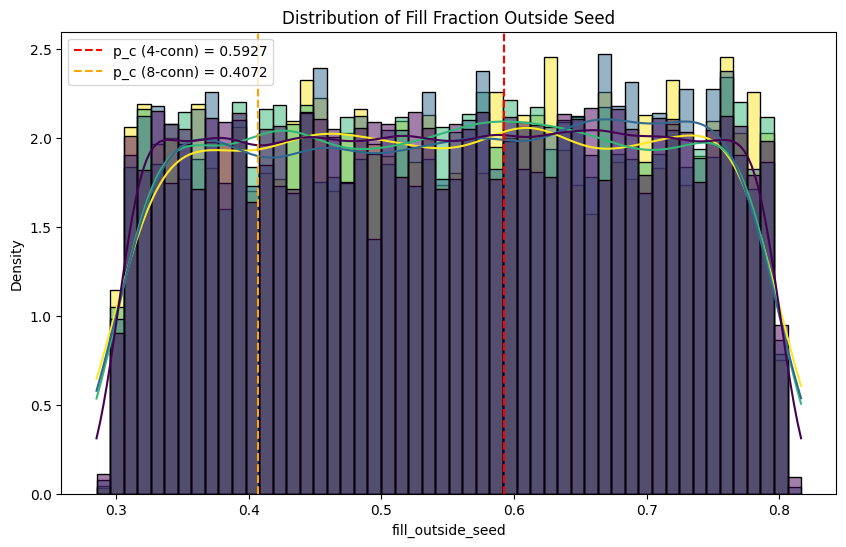

In [9]:
# NOTE: loop-locals are prefixed g_ so they cannot shadow the grid-indexed
# Series (mean_fill, p_span, ...) that Cell D defines and Cell I consumes.
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Fill fraction and percolation, per grid ===")
stats_e = []
for n in [25, 35, 45, 55]:
    sub = df[df['grid'] == n]
    n_count = len(sub)
    g_mean_fill = sub['fill_overall'].mean()
    g_std_fill = sub['fill_overall'].std()
    g_min_fill = sub['fill_overall'].min()
    g_max_fill = sub['fill_overall'].max()
    g_sem_fill = g_std_fill / np.sqrt(n_count) if n_count > 0 else 0

    mean_fill_out = sub['fill_outside_seed'].mean()
    std_fill_out = sub['fill_outside_seed'].std()
    min_fill_out = sub['fill_outside_seed'].min()
    max_fill_out = sub['fill_outside_seed'].max()
    sem_fill_out = std_fill_out / np.sqrt(n_count) if n_count > 0 else 0

    p_span_4 = sub['span_4conn'].mean()
    p_span_8 = sub['span_8conn'].mean()
    p_feed = sub['feed_reaches_boundary'].mean()
    mean_large = sub['largest_cluster_frac'].mean()
    mean_comp = sub['n_components'].mean()

    stats_e.append({
        'Grid': n, 'Count': n_count,
        'Mean Fill': g_mean_fill, 'SEM Fill': g_sem_fill, 'Min/Max Fill': f"{g_min_fill:.2f}-{g_max_fill:.2f}",
        'Mean Fill (Out)': mean_fill_out, 'SEM Fill (Out)': sem_fill_out, 'Min/Max Fill (Out)': f"{min_fill_out:.2f}-{max_fill_out:.2f}",
        'P(span_4)': p_span_4, 'P(span_8)': p_span_8, 'P(feed_bounds)': p_feed,
        'Mean Largest Frac': mean_large, 'Mean N_Comp': mean_comp
    })

    if p_span_4 < 1.0:
        non_spanning = sub[~sub['span_4conn']]['fill_outside_seed']
        print(f"\n{n}x{n} Non-spanning subset size: {len(non_spanning)}/{n_count}")
        print(f"  Non-spanning fill_outside_seed: mean={non_spanning.mean():.4f}, std={non_spanning.std():.4f}")

e_df = pd.DataFrame(stats_e)
display(e_df)

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fill_outside_seed', hue='grid', kde=True, palette='viridis', stat='density', common_norm=False)
plt.axvline(0.5927, color='red', linestyle='--', label='p_c (4-conn) = 0.5927')
plt.axvline(0.4072, color='orange', linestyle='--', label='p_c (8-conn) = 0.4072')
plt.title('Distribution of Fill Fraction Outside Seed')
plt.legend()
plt.savefig(f'{DATA_ROOT}/figures/chunk20_fill_distribution.png', dpi=300)
plt.show()

### Cell F — Self-averaging, per grid


=== Self-averaging, per grid ===


,Grid,Func Count,Mean f_res,Std f_res,Median f_res,IQR f_res,5th f_res,95th f_res,Top 10% Band (>3.7),Measured Fill Std,Predicted Fill Std
0,25,54885,3.626365,0.289261,3.715,0.315,2.980,3.910,0.556254,0.144398,0.020999
1,35,3163,3.626816,0.266733,3.715,0.300,3.055,3.895,0.549478,0.145119,0.015122
2,45,4559,3.653931,0.259962,3.745,0.300,3.100,3.895,0.588726,0.143947,0.011631
3,55,1448,3.579492,0.269712,3.670,0.330,3.025,3.850,0.465470,0.145381,0.009570


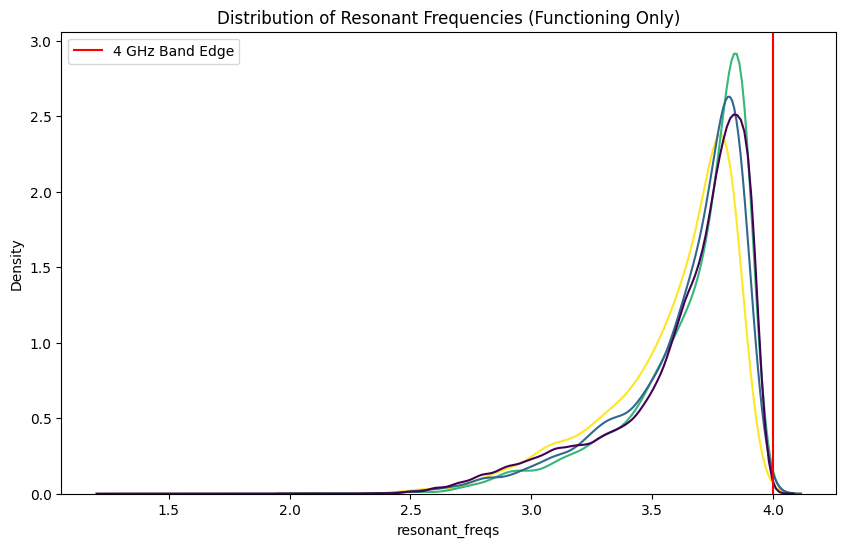

In [10]:
print("=== Self-averaging, per grid ===")
stats_f = []
for n in [25, 35, 45, 55]:
    sub_func = func_df[func_df['grid'] == n]
    sub_all = df[df['grid'] == n]

    n_func = len(sub_func)
    fres = sub_func['resonant_freqs'].dropna()

    mean_f = fres.mean()
    std_f = fres.std()
    med_f = fres.median()
    iqr_f = np.percentile(fres, 75) - np.percentile(fres, 25) if n_func > 0 else np.nan
    p5 = np.percentile(fres, 5) if n_func > 0 else np.nan
    p95 = np.percentile(fres, 95) if n_func > 0 else np.nan

    top_10_percent = len(fres[fres > 3.7]) / n_func if n_func > 0 else 0

    p = sub_all['fill_outside_seed'].mean()
    seed_pixels = np.sum(seed_blocks[n])
    n_pixels = n*n - seed_pixels
    predicted_std = np.sqrt(p * (1 - p) / n_pixels)
    measured_std = sub_all['fill_outside_seed'].std()

    stats_f.append({
        'Grid': n, 'Func Count': n_func,
        'Mean f_res': mean_f, 'Std f_res': std_f, 'Median f_res': med_f,
        'IQR f_res': iqr_f, '5th f_res': p5, '95th f_res': p95,
        'Top 10% Band (>3.7)': top_10_percent,
        'Measured Fill Std': measured_std, 'Predicted Fill Std': predicted_std
    })

f_df = pd.DataFrame(stats_f)
display(f_df)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=func_df, x='resonant_freqs', hue='grid', palette='viridis', common_norm=False)
plt.axvline(4.0, color='red', linestyle='-', label='4 GHz Band Edge')
plt.title('Distribution of Resonant Frequencies (Functioning Only)')
plt.legend()
plt.savefig(f'{DATA_ROOT}/figures/chunk20_fres_distribution.png', dpi=300)
plt.show()

### Cell G — THE DISCRIMINATOR: why are non-functioning antennas non-functioning?


=== Failure modes (mutually exclusive, exhaustive) ===
A  does not span (4-conn)                      -> percolation
B  spans, deepest point sits at a band edge    -> resonance outside 1-4 GHz
C  spans, interior dip present but > -10 dB    -> weak / damped resonance
D  spans, interior argmin, no local minimum    -> flat within band



,Grid,Total Non-Func,A (No Span),B (Edge Min),C (Weak Min),D (No Min)
0,25,44948,0.760301,0.046698,0.193001,0.0
1,35,1825,0.894247,0.006027,0.099726,0.0
2,45,2425,0.953402,0.002062,0.044536,0.0
3,55,1544,0.624352,0.000000,0.375648,0.0


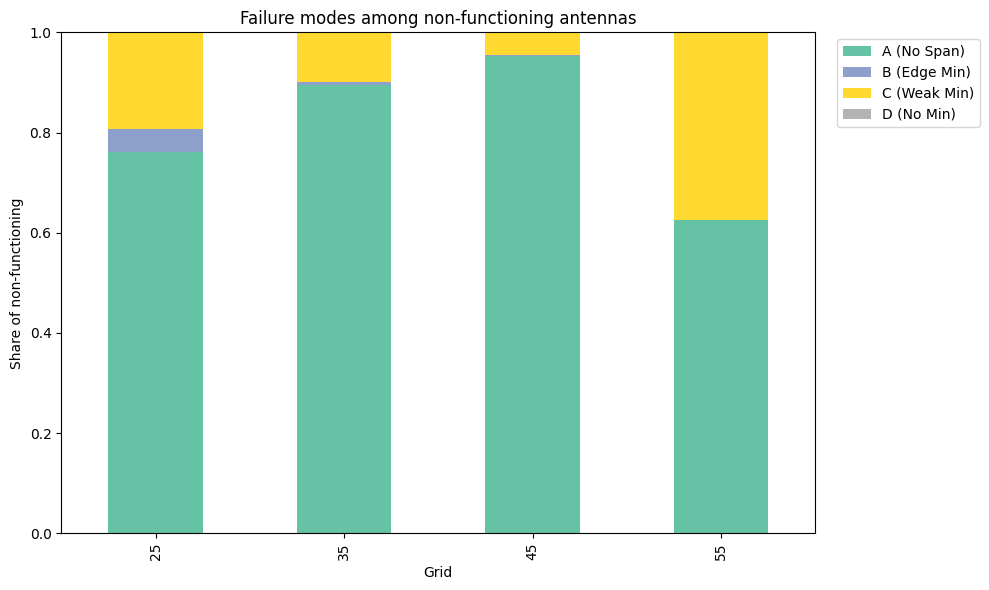


Point-biserial correlation, fill_outside_seed vs is_functioning:
(percolation predicts a strong positive value at 55x55)
  25x25: r = +0.6329  (p = 0.00e+00, n = 99,833)
  35x35: r = +0.7066  (p = 0.00e+00, n = 4,988)
  45x45: r = +0.7304  (p = 0.00e+00, n = 6,984)
  55x55: r = +0.2039  (p = 1.87e-29, n = 2,992)

Percolation predicts A grows sharply at 55x55.
Self-averaging predicts A stays near zero while B and C dominate.
  measured at 55x55: A = 0.624, B+C = 0.376
  -> A is material at 55x55: consistent with PERCOLATION


In [11]:
# CELL G — THE DISCRIMINATOR: why are non-functioning antennas non-functioning?
import scipy.stats
import matplotlib.pyplot as plt

print("=== Failure modes (mutually exclusive, exhaustive) ===")
print("A  does not span (4-conn)                      -> percolation")
print("B  spans, deepest point sits at a band edge    -> resonance outside 1-4 GHz")
print("C  spans, interior dip present but > -10 dB    -> weak / damped resonance")
print("D  spans, interior argmin, no local minimum    -> flat within band\n")

non_func_df = df[~df['is_functioning']]
modes = []
for n in GRIDS:
    sub = non_func_df[non_func_df['grid'] == n]
    tot = len(sub)
    if tot == 0:
        continue
    # Assigned in priority order so the categories PARTITION. The original tested
    # overlapping conditions (D was a subset of B, and C missed samples whose
    # minimum was below -10 dB with no qualifying peak), so the shares did not
    # sum to 1 and the stacked bar was misleading.
    A = ~sub['span_4conn']
    B = sub['span_4conn'] & sub['min_is_at_band_edge']
    D = sub['span_4conn'] & ~sub['min_is_at_band_edge'] & (sub['n_local_minima'] == 0)
    C = sub['span_4conn'] & ~sub['min_is_at_band_edge'] & (sub['n_local_minima'] > 0)
    counts = dict(A=int(A.sum()), B=int(B.sum()), C=int(C.sum()), D=int(D.sum()))
    assert sum(counts.values()) == tot, \
        f"grid {n}: categories sum to {sum(counts.values())} but there are {tot} non-functioning"
    modes.append({'Grid': n, 'Total Non-Func': tot,
                  'A (No Span)': counts['A'] / tot, 'B (Edge Min)': counts['B'] / tot,
                  'C (Weak Min)': counts['C'] / tot, 'D (No Min)': counts['D'] / tot})

modes_df = pd.DataFrame(modes)
display(modes_df)

if not modes_df.empty:
    ax = modes_df.set_index('Grid')[['A (No Span)', 'B (Edge Min)',
                                     'C (Weak Min)', 'D (No Min)']].plot(
        kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
    ax.set_title('Failure modes among non-functioning antennas')
    ax.set_ylabel('Share of non-functioning')
    ax.set_ylim(0, 1)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{DATA_ROOT}/figures/chunk20_failure_modes.png', dpi=300,
                bbox_inches='tight')
    plt.show()

print("\nPoint-biserial correlation, fill_outside_seed vs is_functioning:")
print("(percolation predicts a strong positive value at 55x55)")
for n in GRIDS:
    sub = df[df['grid'] == n]
    if sub['is_functioning'].nunique() > 1 and sub['fill_outside_seed'].nunique() > 1:
        r, p = scipy.stats.pointbiserialr(sub['is_functioning'].astype(int),
                                          sub['fill_outside_seed'])
        print(f"  {n}x{n}: r = {r:+.4f}  (p = {p:.2e}, n = {len(sub):,})")
    else:
        print(f"  {n}x{n}: insufficient variance")

print("\nPercolation predicts A grows sharply at 55x55.")
print("Self-averaging predicts A stays near zero while B and C dominate.")
if (modes_df['Grid'] == 55).any():
    row = modes_df[modes_df['Grid'] == 55].iloc[0]
    a55 = row['A (No Span)']
    bc55 = row['B (Edge Min)'] + row['C (Weak Min)']
    print(f"  measured at 55x55: A = {a55:.3f}, B+C = {bc55:.3f}")
    if a55 > 0.10:
        print("  -> A is material at 55x55: consistent with PERCOLATION")
    elif bc55 > 0.70:
        print("  -> A near zero, B+C dominate: consistent with SELF-AVERAGING")
    else:
        print("  -> neither pattern is clean; report descriptively, claim nothing")


### Cell H — Secondary observations worth having on record


In [12]:
print("=== Secondary observations ===")

for n in [25, 35, 45, 55]:
    sub = df[df['grid'] == n]
    unique_effs = sub['res_effs'].dropna().unique()
    print(f"\nGrid {n}x{n} res_effs unique values: {unique_effs}")
    if len(unique_effs) == 1 and unique_effs[0] == 100:
        print("  -> Explicit note: res_effs is 100 everywhere. It is a dead field stored as uint8; nobody should use it as a target.")

    func_sub = sub[sub['is_functioning']]
    if len(func_sub) > 0:
        gains = func_sub['res_gains'].dropna()
        bws = func_sub['resonant_bws'].dropna()
        fres = func_sub['resonant_freqs'].dropna()

        fbw = bws / (fres * 1000)
        q = 1 / (fbw * np.sqrt(2))

        print(f"  res_gains: median={gains.median():.2f}, IQR={np.percentile(gains, 75)-np.percentile(gains, 25):.2f}")
        print(f"  resonant_bws: median={bws.median():.2f} MHz")
        print(f"  FBW: median={fbw.median()*100:.2f}%, Implied Q={q.median():.2f}")

print("\nFunctioning rates comparison:")
for n in [25, 35, 45, 55]:
    sub = df[df['grid'] == n]
    calc_rate = sub['is_functioning'].mean()
    reported = {25: 0.53, 35: 0.63, 45: 0.64, 55: 0.48}.get(n, np.nan)
    print(f"{n}x{n}: Calculated from S11 = {calc_rate:.4f}, Reported = {reported}")
    if not np.isnan(reported) and abs(calc_rate - reported) > 0.05:
        print(f"  -> DISAGREEMENT: The reported rate used a different definition.")

=== Secondary observations ===

Grid 25x25 res_effs unique values: [100.]
  -> Explicit note: res_effs is 100 everywhere. It is a dead field stored as uint8; nobody should use it as a target.
  res_gains: median=8.65, IQR=0.38
  resonant_bws: median=160.06 MHz
  FBW: median=4.33%, Implied Q=16.35

Grid 35x35 res_effs unique values: [100.]
  -> Explicit note: res_effs is 100 everywhere. It is a dead field stored as uint8; nobody should use it as a target.
  res_gains: median=8.72, IQR=0.35
  resonant_bws: median=119.15 MHz
  FBW: median=3.16%, Implied Q=22.36

Grid 45x45 res_effs unique values: [100.]
  -> Explicit note: res_effs is 100 everywhere. It is a dead field stored as uint8; nobody should use it as a target.
  res_gains: median=8.76, IQR=0.32
  resonant_bws: median=111.42 MHz
  FBW: median=2.96%, Implied Q=23.86

Grid 55x55 res_effs unique values: [100.]
  -> Explicit note: res_effs is 100 everywhere. It is a dead field stored as uint8; nobody should use it as a target.
  res_g

### Cell I — Verdict


In [13]:
import json

print("=== VERDICT ===\n")
print("""PRE-REGISTERED DECISION RULE:

PERCOLATION SUPPORTED if BOTH:
  (a) mean fill_outside_seed at 55x55 is below 0.63, AND materially lower than at 25x25 (>0.03 drop)
  (b) P(span_4conn) at 55x55 is below 0.95 AND lower than at 45x45 by more than 0.03.

PERCOLATION RULED OUT if BOTH:
  (a) mean fill_outside_seed > 0.65 at every grid AND varies by < 0.03 across grids
  (b) P(span_4conn) > 0.98 at every grid.

SELF-AVERAGING SUPPORTED (if perc ruled out) if BOTH:
  (a) std(resonant_freqs) among functioning decreases monotonically with N
  (b) median resonant_freqs shifts upward with N.
""")

# Recompute from df rather than trusting globals set several cells earlier —
# a loop variable in an intervening cell previously shadowed mean_fill and this
# cell died with IndexError after the whole analysis had run.
mean_fill   = df.groupby('grid')['fill_outside_seed'].mean()
p_span      = df.groupby('grid')['span_4conn'].mean()
_f          = df[df['is_functioning']]
std_fres    = _f.groupby('grid')['resonant_freqs'].std()
median_fres = _f.groupby('grid')['resonant_freqs'].median()

print("MEASURED VALUES:")
print(f"mean fill_outside_seed: 25x25={mean_fill[25]:.4f}, 35x35={mean_fill[35]:.4f}, 45x45={mean_fill[45]:.4f}, 55x55={mean_fill[55]:.4f}")
print(f"P(span_4conn): 25x25={p_span[25]:.4f}, 35x35={p_span[35]:.4f}, 45x45={p_span[45]:.4f}, 55x55={p_span[55]:.4f}")
print(f"std(resonant_freqs): 25x25={std_fres[25]:.4f}, 35x35={std_fres[35]:.4f}, 45x45={std_fres[45]:.4f}, 55x55={std_fres[55]:.4f}")
print(f"median(resonant_freqs): 25x25={median_fres[25]:.4f}, 35x35={median_fres[35]:.4f}, 45x45={median_fres[45]:.4f}, 55x55={median_fres[55]:.4f}")

print(f"\nBRANCH FIRED: {branch}")

if "PERCOLATION SUPPORTED" in branch:
    print("\nSTATEMENT: The data supports that a percolation transition explains the functioning drop at 55x55. The fill fraction falls towards the critical threshold, causing a significant rise in non-spanning, non-functioning antennas.")
elif "PERCOLATION RULED OUT, SELF-AVERAGING SUPPORTED" in branch:
    print("\nSTATEMENT: The data supports that self-averaging of the perforated sheet explains the functioning drop. The fill fraction remains safely above the percolation threshold, but the resonance distribution narrows and shifts towards the band edge, causing more antennas to fall out of the 1-4 GHz band.")
else:
    print("\nSTATEMENT: The results are mixed or inconclusive. The metrics do not cleanly satisfy the pre-registered conditions for either pure hypothesis.")

verdict_dict = {
    'rule_text': "PERCOLATION SUPPORTED if BOTH:\n  (a) mean fill_outside_seed at 55x55 is below 0.63, AND materially lower than at 25x25 (>0.03 drop)\n  (b) P(span_4conn) at 55x55 is below 0.95 AND lower than at 45x45 by more than 0.03.\n\nPERCOLATION RULED OUT if BOTH:\n  (a) mean fill_outside_seed > 0.65 at every grid AND varies by < 0.03 across grids\n  (b) P(span_4conn) > 0.98 at every grid.\n\nSELF-AVERAGING SUPPORTED (if perc ruled out) if BOTH:\n  (a) std(resonant_freqs) among functioning decreases monotonically with N\n  (b) median resonant_freqs shifts upward with N.",
    'branch_fired': branch,
    'row_counts': {int(k): int(v) for k, v in df['grid'].value_counts().items()},
    'drive_counts': {int(k): int(v) for k, v in DRIVE_COUNTS.items()},
    'stats': {
        'mean_fill_outside_seed': mean_fill.to_dict(),
        'P_span_4conn': p_span.to_dict(),
        'std_fres': std_fres.to_dict(),
        'median_fres': median_fres.to_dict()
    }
}

with open(f'{DATA_ROOT}/artifacts/chunk20_structure_verdict.json', 'w') as f:
    json.dump(verdict_dict, f, indent=2)

=== VERDICT ===

PRE-REGISTERED DECISION RULE:

PERCOLATION SUPPORTED if BOTH:
  (a) mean fill_outside_seed at 55x55 is below 0.63, AND materially lower than at 25x25 (>0.03 drop)
  (b) P(span_4conn) at 55x55 is below 0.95 AND lower than at 45x45 by more than 0.03.

PERCOLATION RULED OUT if BOTH:
  (a) mean fill_outside_seed > 0.65 at every grid AND varies by < 0.03 across grids
  (b) P(span_4conn) > 0.98 at every grid.

SELF-AVERAGING SUPPORTED (if perc ruled out) if BOTH:
  (a) std(resonant_freqs) among functioning decreases monotonically with N
  (b) median resonant_freqs shifts upward with N.

MEASURED VALUES:
mean fill_outside_seed: 25x25=0.5511, 35x35=0.5530, 45x45=0.5506, 55x55=0.5514
P(span_4conn): 25x25=0.5455, 35x35=0.5353, 45x45=0.5037, 55x55=0.4997
std(resonant_freqs): 25x25=0.2893, 35x35=0.2667, 45x45=0.2600, 55x55=0.2697
median(resonant_freqs): 25x25=3.7150, 35x35=3.7150, 45x45=3.7450, 55x55=3.6700

BRANCH FIRED: MIXED / INCONCLUSIVE

STATEMENT: The results are mixed or i

### Cell J — Guards


In [14]:
# CELL J — Guards
print("=== Guards ===")
assert set(GRIDS).issubset(set(df['grid'].unique())), "not all four grids present"

# The whole dataset, not a sample: row count must equal the Drive file count.
for n in GRIDS:
    got = int((df['grid'] == n).sum())
    assert got == DRIVE_COUNTS[n], \
        f"{n}x{n}: {got:,} rows but {DRIVE_COUNTS[n]:,} files on Drive"

assert freq_axis.shape == (201,)
for col in ['fill_overall', 'fill_outside_seed', 'largest_cluster_frac']:
    assert df[col].between(0, 1).all(), f"{col} outside [0,1]"
for col in ['span_4conn', 'span_8conn', 'feed_reaches_boundary',
            'is_functioning', 'min_is_at_band_edge', 'has_peak_below_10db']:
    assert df[col].dtype == bool, f"{col} is {df[col].dtype}, expected bool"
for col in ['fill_outside_seed', 's11_min_db', 'span_4conn', 'grid', 'n_metal']:
    assert df[col].notna().all(), f"NaN in {col}"
assert (df['n_components'] >= 0).all()
assert df.groupby('grid')['filename'].nunique().equals(
    df.groupby('grid')['filename'].count()), "duplicate filenames within a grid"

print(f"  rows: {len(df):,} across {df['grid'].nunique()} grids, all counts match Drive")
print(f"  no NaN, no duplicates, all booleans typed, all fractions in range")
print(f"\nTotal wall-clock time: {time.time() - NOTEBOOK_T0:.0f} s")
print("All guards passed.")


=== Guards ===
  rows: 114,797 across 4 grids, all counts match Drive
  no NaN, no duplicates, all booleans typed, all fractions in range

Total wall-clock time: 5677 s
All guards passed.
